In [22]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.feature_selection import SelectKBest, chi2, mutual_info_classif

In [2]:
column_names = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 
                'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']
data = pd.read_csv('pima-indians-diabetes.data.csv', header=None, names=column_names)

In [3]:
data = data[data['Glucose'] > 0]
data['Outcome_Label'] = data['Outcome'].map({0: 'Không mắc', 1: 'Mắc bệnh'})


C:\Users\Dat\AppData\Local\Temp\ipykernel_6876\3648675257.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x='Outcome_Label', y='Glucose', ax=axes[0, 1], palette='Blues_d')


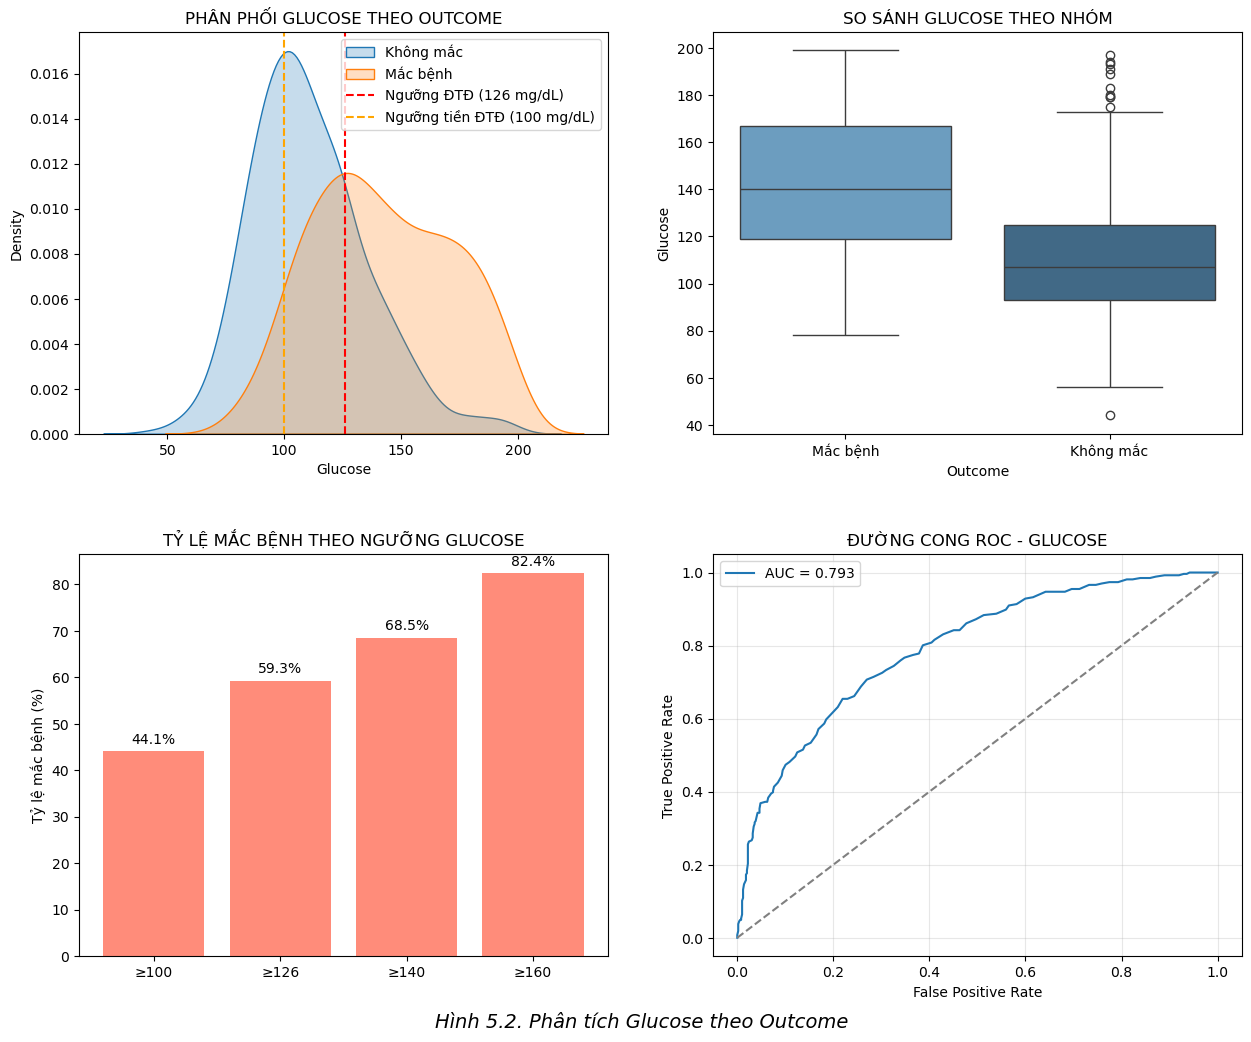

In [5]:
# 2. Khởi tạo Figure với 2 hàng và 2 cột
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
plt.subplots_adjust(hspace=0.3, wspace=0.2)

# --- BIỂU ĐỒ 1: PHÂN PHỐI GLUCOSE (KDE Plot) ---
sns.kdeplot(data=data[data['Outcome']==0]['Glucose'], fill=True, ax=axes[0, 0], label='Không mắc', color='#1f77b4')
sns.kdeplot(data=data[data['Outcome']==1]['Glucose'], fill=True, ax=axes[0, 0], label='Mắc bệnh', color='#ff7f0e')
axes[0, 0].axvline(126, color='red', linestyle='--', label='Ngưỡng ĐTĐ (126 mg/dL)')
axes[0, 0].axvline(100, color='orange', linestyle='--', label='Ngưỡng tiền ĐTĐ (100 mg/dL)')
axes[0, 0].set_title('PHÂN PHỐI GLUCOSE THEO OUTCOME')
axes[0, 0].legend()

# --- BIỂU ĐỒ 2: SO SÁNH GLUCOSE (Boxplot) ---
sns.boxplot(data=data, x='Outcome_Label', y='Glucose', ax=axes[0, 1], palette='Blues_d')
axes[0, 1].set_title('SO SÁNH GLUCOSE THEO NHÓM')
axes[0, 1].set_xlabel('Outcome')

# --- BIỂU ĐỒ 3: TỶ LỆ MẮC BỆNH THEO NGƯỠNG (Bar Chart) ---
thresholds = [100, 126, 140, 160]
ratios = []
for t in thresholds:
    subset = data[data['Glucose'] >= t]
    ratio = (subset['Outcome'].sum() / len(subset)) * 100
    ratios.append(ratio)

bars = axes[1, 0].bar([f'≥{t}' for t in thresholds], ratios, color='#ff8c7a')
axes[1, 0].set_title('TỶ LỆ MẮC BỆNH THEO NGƯỠNG GLUCOSE')
axes[1, 0].set_ylabel('Tỷ lệ mắc bệnh (%)')
for bar in bars:
    yval = bar.get_height()
    axes[1, 0].text(bar.get_x() + bar.get_width()/2, yval + 1, f'{yval:.1f}%', ha='center', va='bottom')

# --- BIỂU ĐỒ 4: ĐƯỜNG CONG ROC - GLUCOSE ---
fpr, tpr, _ = roc_curve(data['Outcome'], data['Glucose'])
roc_auc = auc(fpr, tpr)
axes[1, 1].plot(fpr, tpr, label=f'AUC = {roc_auc:.3f}')
axes[1, 1].plot([0, 1], [0, 1], color='gray', linestyle='--')
axes[1, 1].set_title('ĐƯỜNG CONG ROC - GLUCOSE')
axes[1, 1].set_xlabel('False Positive Rate')
axes[1, 1].set_ylabel('True Positive Rate')
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

# Chú thích hình tổng quát
plt.figtext(0.5, 0.05, 'Hình 5.2. Phân tích Glucose theo Outcome', 
            ha='center', fontsize=14, style='italic')

plt.show()

In [6]:
# Tiền xử lý: Lọc bỏ giá trị bằng 0 (nhiễu) cho cả BMI và SkinThickness
data = data[(data['BMI'] > 0) & (data['SkinThickness'] > 0)]

# Phân nhóm BMI để vẽ Boxplot
def categorize_bmi(bmi):
    if bmi < 25: return 'Bình thường'
    elif bmi < 30: return 'Thừa cân'
    else: return 'Béo phì'

data['BMI_Group'] = data['BMI'].apply(categorize_bmi)


C:\Users\Dat\AppData\Local\Temp\ipykernel_6876\1859330207.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x='BMI_Group', y='SkinThickness', order=order,


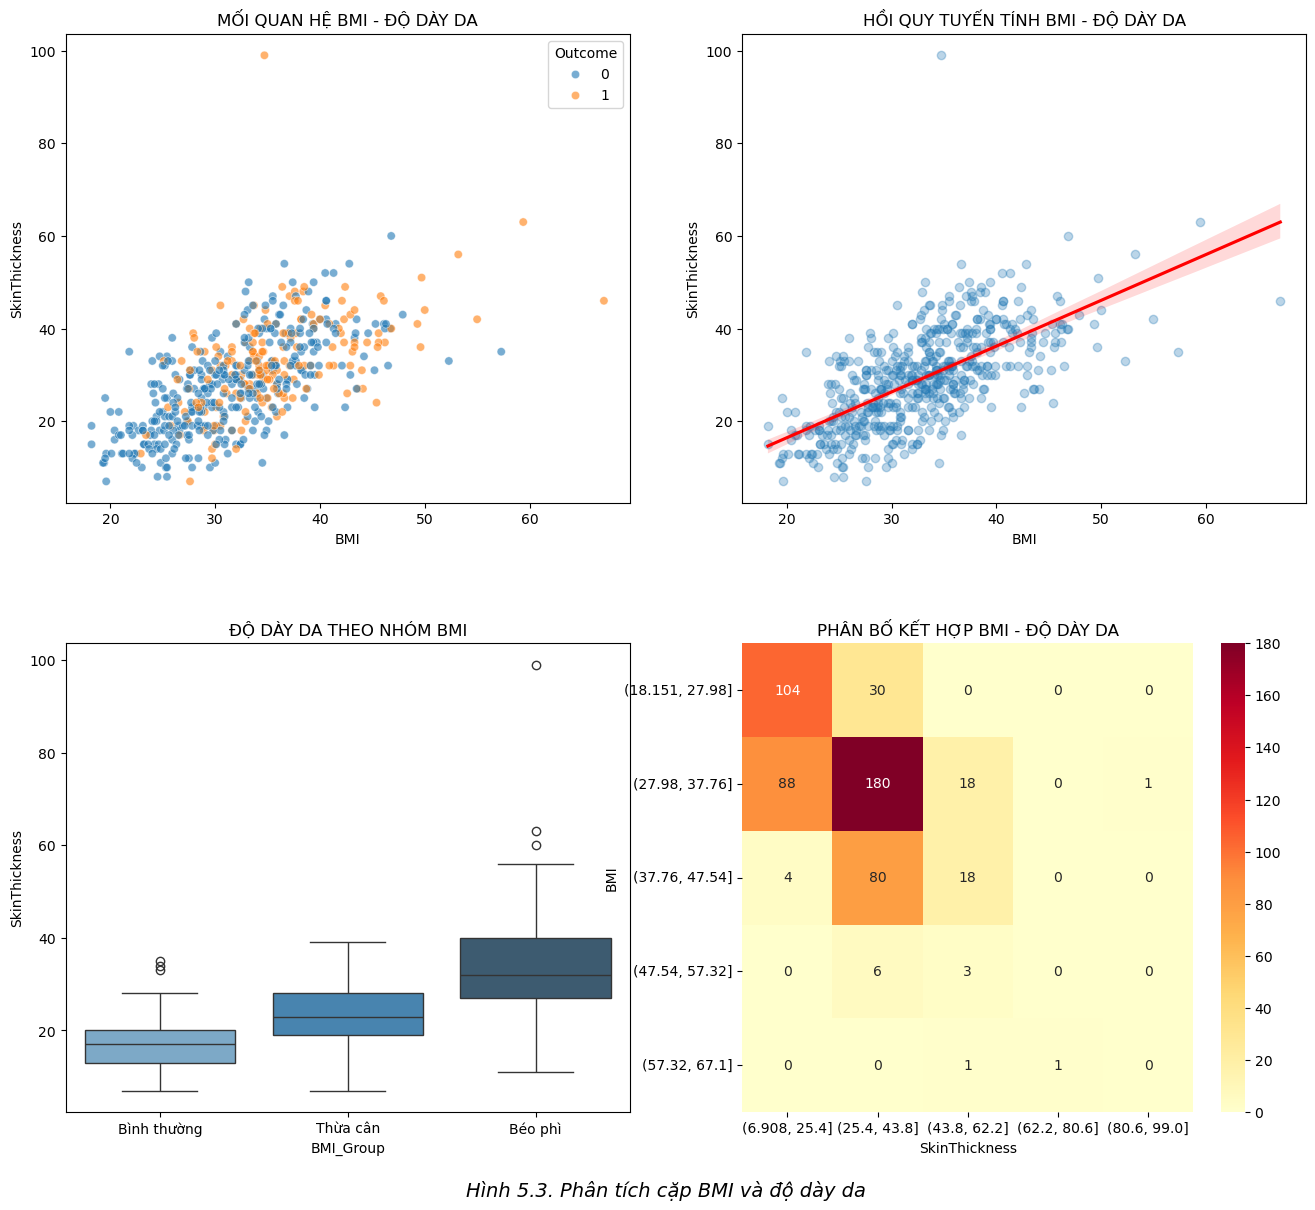

In [7]:
# 2. Khởi tạo Figure 2x2
fig, axes = plt.subplots(2, 2, figsize=(16, 14))
plt.subplots_adjust(hspace=0.3, wspace=0.2)

# --- BIỂU ĐỒ 1: MỐI QUAN HỆ BMI - ĐỘ DÀY DA (Scatter Plot) ---
sns.scatterplot(data=data, x='BMI', y='SkinThickness', hue='Outcome', 
                palette='tab10', alpha=0.6, ax=axes[0, 0])
axes[0, 0].set_title('MỐI QUAN HỆ BMI - ĐỘ DÀY DA')

# --- BIỂU ĐỒ 2: HỒI QUY TUYẾN TÍNH (Regplot) ---
sns.regplot(data=data, x='BMI', y='SkinThickness', scatter_kws={'alpha':0.3}, 
            line_kws={'color':'red'}, ax=axes[0, 1])
axes[0, 1].set_title('HỒI QUY TUYẾN TÍNH BMI - ĐỘ DÀY DA')

# --- BIỂU ĐỒ 3: ĐỘ DÀY DA THEO NHÓM BMI (Boxplot) ---
order = ['Bình thường', 'Thừa cân', 'Béo phì']
sns.boxplot(data=data, x='BMI_Group', y='SkinThickness', order=order, 
            palette='Blues_d', ax=axes[1, 0])
axes[1, 0].set_title('ĐỘ DÀY DA THEO NHÓM BMI')

# --- BIỂU ĐỒ 4: PHÂN BỐ KẾT HỢP (Heatmap/2D Hist) ---
# Sử dụng pd.cut để tạo các khoảng (bins) cho Heatmap
bmi_bins = pd.cut(data['BMI'], bins=5)
skin_bins = pd.cut(data['SkinThickness'], bins=5)
heatmap_data = pd.crosstab(bmi_bins, skin_bins)

sns.heatmap(heatmap_data, annot=True, fmt="d", cmap="YlOrRd", ax=axes[1, 1])
axes[1, 1].set_title('PHÂN BỐ KẾT HỢP BMI - ĐỘ DÀY DA')

# Chú thích tổng quát
plt.figtext(0.5, 0.05, 'Hình 5.3. Phân tích cặp BMI và độ dày da', 
            ha='center', fontsize=14, style='italic')

plt.show()

In [8]:
# Tiền xử lý dữ liệu cho biểu đồ cột
bins = [20, 30, 40, 50, 100]
labels = ['(20, 30]', '(30, 40]', '(40, 50]', '(50, 100]']
data['AgeGroup'] = pd.cut(data['Age'], bins=bins, labels=labels)
avg_preg = data.groupby('AgeGroup')['Pregnancies'].mean().reset_index()


C:\Users\Dat\AppData\Local\Temp\ipykernel_6876\146153475.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_preg = data.groupby('AgeGroup')['Pregnancies'].mean().reset_index()


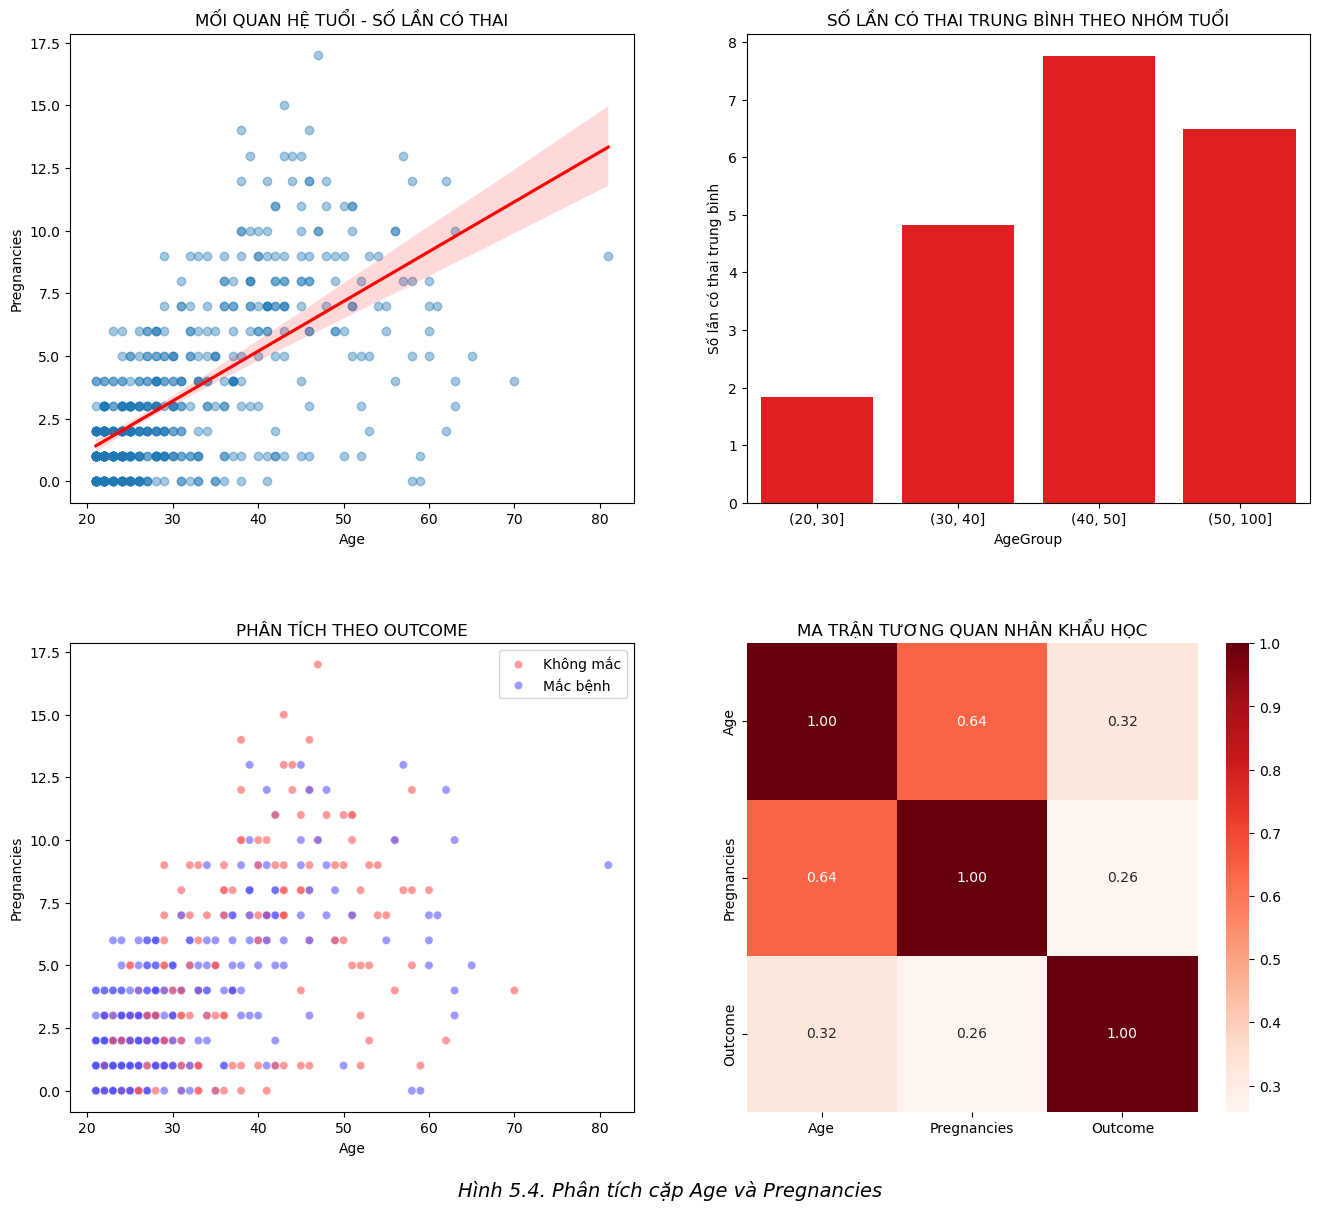

In [9]:
# 2. Khởi tạo Figure 2x2
fig, axes = plt.subplots(2, 2, figsize=(16, 14))
plt.subplots_adjust(hspace=0.3, wspace=0.2)

# --- BIỂU ĐỒ 1: MỐI QUAN HỆ TUỔI - SỐ LẦN CÓ THAI (Regplot) ---
sns.regplot(data=data, x='Age', y='Pregnancies', scatter_kws={'alpha':0.4}, 
            line_kws={'color':'red'}, ax=axes[0, 0])
axes[0, 0].set_title('MỐI QUAN HỆ TUỔI - SỐ LẦN CÓ THAI')

# --- BIỂU ĐỒ 2: SỐ LẦN CÓ THAI TRUNG BÌNH THEO NHÓM TUỔI (Bar Chart) ---
sns.barplot(data=avg_preg, x='AgeGroup', y='Pregnancies', color='red', ax=axes[0, 1])
axes[0, 1].set_title('SỐ LẦN CÓ THAI TRUNG BÌNH THEO NHÓM TUỔI')
axes[0, 1].set_ylabel('Số lần có thai trung bình')

# --- BIỂU ĐỒ 3: PHÂN TÍCH THEO OUTCOME (Scatter Plot) ---
sns.scatterplot(data=data, x='Age', y='Pregnancies', hue='Outcome', 
                palette='seismic', alpha=0.6, ax=axes[1, 0])
axes[1, 0].set_title('PHÂN TÍCH THEO OUTCOME')
axes[1, 0].legend(labels=['Không mắc', 'Mắc bệnh'])

# --- BIỂU ĐỒ 4: MA TRẬN TƯƠNG QUAN NHÂN KHẨU HỌC (Heatmap) ---
corr_matrix = data[['Age', 'Pregnancies', 'Outcome']].corr()
sns.heatmap(corr_matrix, annot=True, cmap='Reds', fmt=".2f", ax=axes[1, 1])
axes[1, 1].set_title('MA TRẬN TƯƠNG QUAN NHÂN KHẨU HỌC')

# Chú thích tổng quát
plt.figtext(0.5, 0.05, 'Hình 5.4. Phân tích cặp Age và Pregnancies', 
            ha='center', fontsize=14, style='italic')

plt.show()

In [10]:
# Tiền xử lý: Lọc bỏ giá trị bằng 0 cho Glucose và Insulin
data = data[(data['Glucose'] > 0) & (data['Insulin'] > 0)]

# Phân nhóm Glucose theo chuẩn lâm sàng
def categorize_glucose(g):
    if g < 100: return 'Bình thường'
    elif g < 126: return 'Tiền ĐTĐ'
    else: return 'ĐTĐ'

data['Glucose_Group'] = data['Glucose'].apply(categorize_glucose)


C:\Users\Dat\AppData\Local\Temp\ipykernel_6876\2179300112.py:23: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_glucose = data.groupby('Insulin_Bin')['Glucose'].mean()


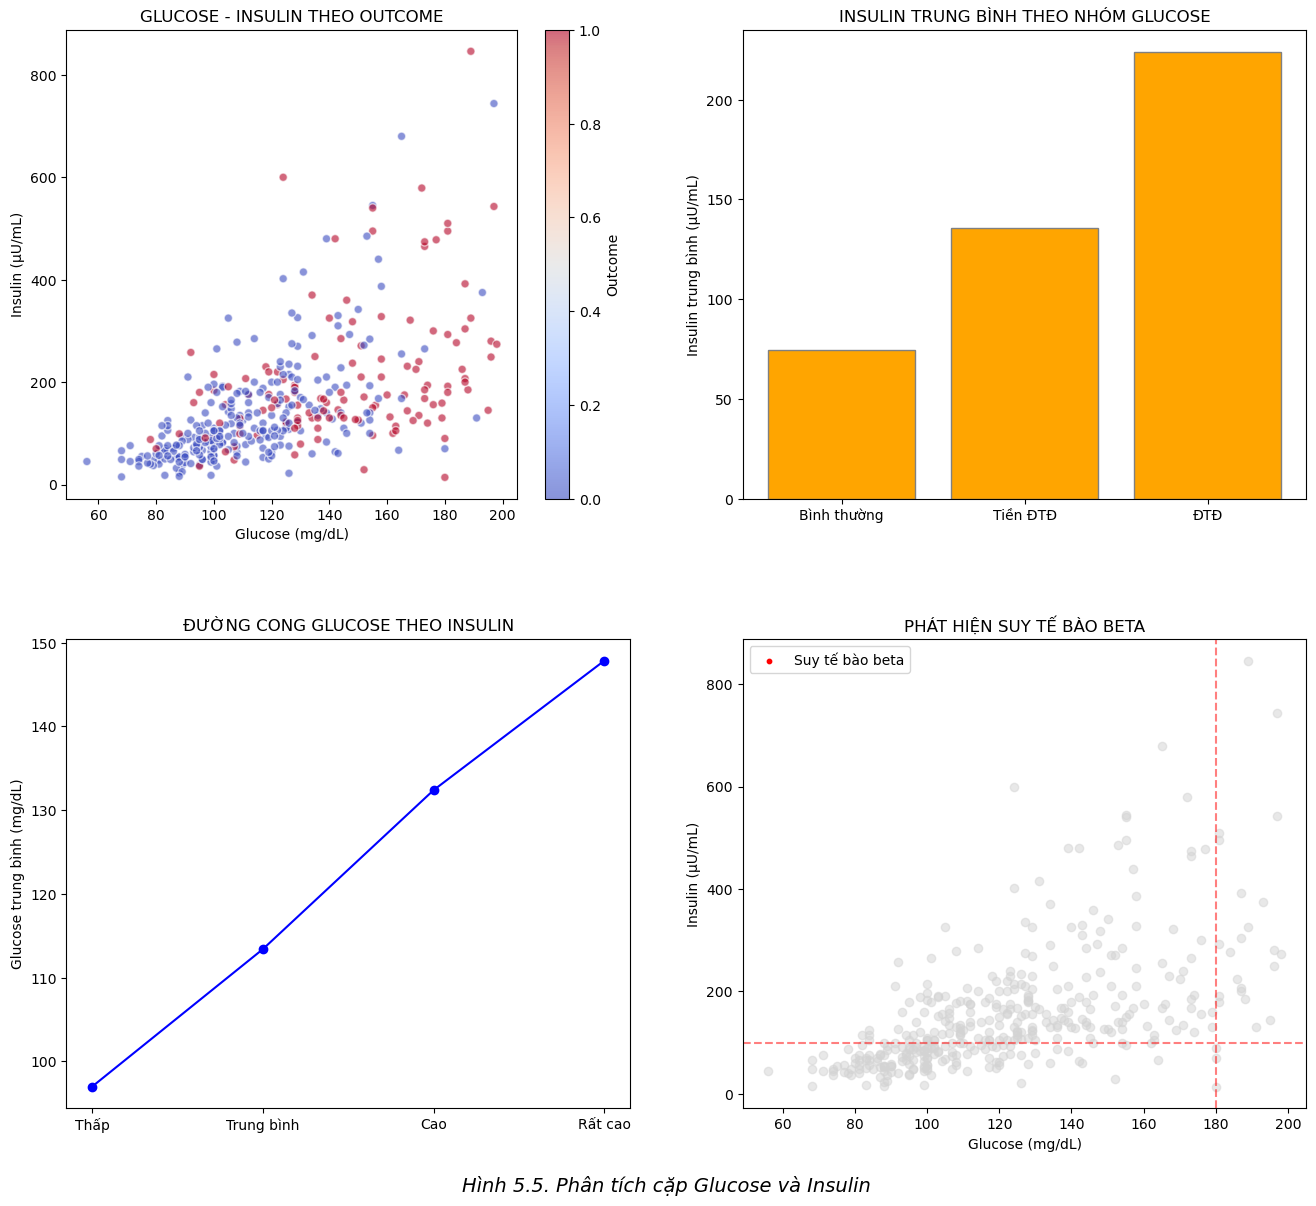

In [11]:
# 2. Khởi tạo Figure 2x2
fig, axes = plt.subplots(2, 2, figsize=(16, 14))
plt.subplots_adjust(hspace=0.3, wspace=0.2)

# --- BIỂU ĐỒ 1: GLUCOSE - INSULIN THEO OUTCOME (Scatter với Colorbar) ---
scatter = axes[0, 0].scatter(data['Glucose'], data['Insulin'], c=data['Outcome'], 
                             cmap='coolwarm', alpha=0.6, edgecolors='w')
axes[0, 0].set_title('GLUCOSE - INSULIN THEO OUTCOME')
axes[0, 0].set_xlabel('Glucose (mg/dL)')
axes[0, 0].set_ylabel('Insulin (µU/mL)')
fig.colorbar(scatter, ax=axes[0, 0], label='Outcome')

# --- BIỂU ĐỒ 2: INSULIN TRUNG BÌNH THEO NHÓM GLUCOSE (Bar Chart) ---
order = ['Bình thường', 'Tiền ĐTĐ', 'ĐTĐ']
avg_insulin = data.groupby('Glucose_Group')['Insulin'].mean().loc[order]
axes[0, 1].bar(avg_insulin.index, avg_insulin.values, color='orange', edgecolor='gray')
axes[0, 1].set_title('INSULIN TRUNG BÌNH THEO NHÓM GLUCOSE')
axes[0, 1].set_ylabel('Insulin trung bình (µU/mL)')

# --- BIỂU ĐỒ 3: ĐƯỜNG CONG GLUCOSE THEO INSULIN (Line Chart) ---
# Chia Insulin thành các phân đoạn (quantiles)
data['Insulin_Bin'] = pd.qcut(data['Insulin'], 4, labels=['Thấp', 'Trung bình', 'Cao', 'Rất cao'])
avg_glucose = data.groupby('Insulin_Bin')['Glucose'].mean()
axes[1, 0].plot(avg_glucose.index, avg_glucose.values, marker='o', color='blue', linestyle='-')
axes[1, 0].set_title('ĐƯỜNG CONG GLUCOSE THEO INSULIN')
axes[1, 0].set_ylabel('Glucose trung bình (mg/dL)')

# --- BIỂU ĐỒ 4: PHÁT HIỆN SUY TẾ BÀO BETA (Scatter với ngưỡng) ---
axes[1, 1].scatter(data['Glucose'], data['Insulin'], color='lightgray', alpha=0.5)
# Giả định ngưỡng suy tế bào beta: Glucose cao nhưng Insulin không tăng tương xứng
beta_failure = data[(data['Glucose'] > 180) & (data['Insulin'] < 100)]
axes[1, 1].scatter(beta_failure['Glucose'], beta_failure['Outcome'], color='red', label='Suy tế bào beta', s=10) 
# Vẽ đường ngưỡng tham chiếu
axes[1, 1].axhline(100, color='red', linestyle='--', alpha=0.5)
axes[1, 1].axvline(180, color='red', linestyle='--', alpha=0.5)
axes[1, 1].set_title('PHÁT HIỆN SUY TẾ BÀO BETA')
axes[1, 1].set_xlabel('Glucose (mg/dL)')
axes[1, 1].set_ylabel('Insulin (µU/mL)')
axes[1, 1].legend()

# Chú thích tổng quát
plt.figtext(0.5, 0.05, 'Hình 5.5. Phân tích cặp Glucose và Insulin', 
            ha='center', fontsize=14, style='italic')

plt.show()

In [14]:
# 2. Đọc dữ liệu
data = pd.read_csv('pima-indians-diabetes.data.csv', header=None, names=column_names)

# Tách đặc trưng (X) và nhãn (y)
X = data.drop('Outcome', axis=1)
y = data['Outcome']

# 3. Tính toán Chi-square và p-value
# Chú ý: Chi-square yêu cầu dữ liệu không âm (tập Pima thỏa mãn điều này)
chi_scores, p_values = chi2(X, y)

# 4. Tạo DataFrame để lưu trữ kết quả
df_chi = pd.DataFrame({
    'Đặc trưng': X.columns,
    'Chi-square': chi_scores,
    'p-value': p_values
})

# 5. Sắp xếp kết quả theo Chi-square giảm dần
df_chi = df_chi.sort_values(by='Chi-square', ascending=False)


In [16]:

# Hiển thị kết quả dạng text trong console để kiểm tra
print(df_chi)

                  Đặc trưng   Chi-square        p-value
4                   Insulin  2175.565273   0.000000e+00
1                   Glucose  1411.887041  5.487286e-309
7                       Age   181.303689   2.516388e-41
5                       BMI   127.669343   1.325908e-29
0               Pregnancies   111.519691   4.552610e-26
3             SkinThickness    53.108040   3.156977e-13
2             BloodPressure    17.605373   2.718193e-05
6  DiabetesPedigreeFunction     5.392682   2.022137e-02


In [19]:
# 2. Tính toán Chi-square scores và p-values
selector = SelectKBest(score_func=chi2, k='all')
selector.fit(X, y)

# Tạo DataFrame kết quả
df_results = pd.DataFrame({
    'Feature': X.columns,
    'Score': selector.scores_,
    'p_value': selector.pvalues_
})

# Sắp xếp theo Score tăng dần để khi vẽ barh nó sẽ hiện từ cao xuống thấp
df_results = df_results.sort_values(by='Score', ascending=True)

# 3. Thiết lập màu sắc dựa trên p-value
# Đỏ nếu p-value < 0.05, Xám nếu ngược lại
colors = ['#ff4d4d' if p < 0.05 else '#a6a6a6' for p in df_results['p_value']]


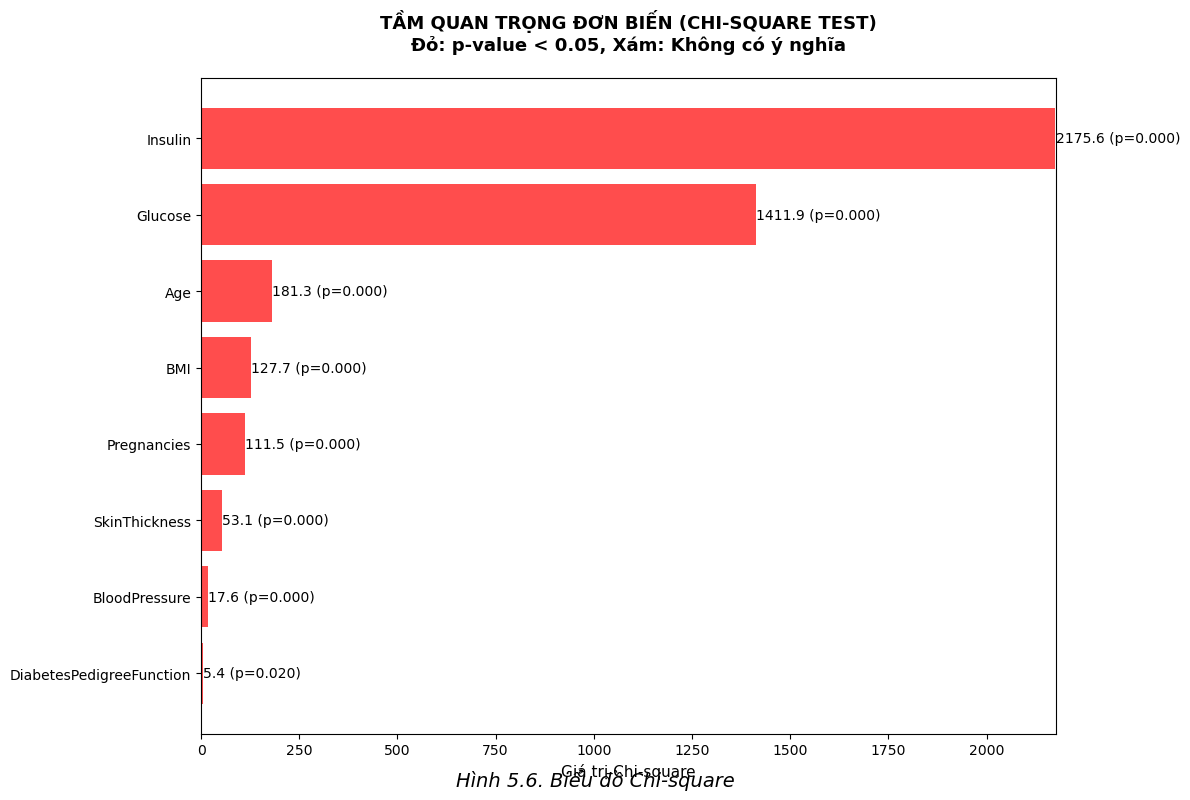

In [20]:
# 4. Vẽ biểu đồ
plt.figure(figsize=(12, 8))
bars = plt.barh(df_results['Feature'], df_results['Score'], color=colors)

# Thêm nhãn text (giá trị và p-value) ở cuối mỗi thanh
for i, bar in enumerate(bars):
    score = df_results['Score'].iloc[i]
    p_val = df_results['p_value'].iloc[i]
    plt.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2, 
             f'{score:.1f} (p={p_val:.3f})', 
             va='center', fontsize=10)

# Tùy chỉnh tiêu đề và nhãn
plt.title('TẦM QUAN TRỌNG ĐƠN BIẾN (CHI-SQUARE TEST)\nĐỏ: p-value < 0.05, Xám: Không có ý nghĩa', 
          fontsize=13, fontweight='bold', pad=20)
plt.xlabel('Giá trị Chi-square', fontsize=11)
plt.xlim(0, max(df_results['Score']) + 2) # Nới rộng trục X để không bị mất chữ

# Thêm chú thích hình bên dưới
plt.figtext(0.5, 0.01, 'Hình 5.6. Biểu đồ Chi-square', 
            ha='center', fontsize=14, style='italic')

plt.tight_layout()
plt.show()

In [23]:
# 3. Tính toán Mutual Information (Thông tin tương hỗ)
# random_state giúp kết quả ổn định qua mỗi lần chạy
mi_scores = mutual_info_classif(X, y, random_state=42)

# 4. Tạo DataFrame kết quả
df_mi = pd.DataFrame({
    'Đặc trưng': X.columns,
    'Mutual Information': mi_scores
})

# 5. Sắp xếp kết quả giảm dần
df_mi = df_mi.sort_values(by='Mutual Information', ascending=False).reset_index(drop=True)

In [24]:
print(df_mi)

                  Đặc trưng  Mutual Information
0                   Glucose            0.114634
1                       BMI            0.080061
2               Pregnancies            0.060985
3                       Age            0.051395
4  DiabetesPedigreeFunction            0.014590
5                   Insulin            0.011948
6             SkinThickness            0.004667
7             BloodPressure            0.000000


In [25]:
from sklearn.ensemble import RandomForestClassifier
# 2. Khởi tạo và huấn luyện mô hình Random Forest
# n_estimators=100: Số lượng cây trong rừng
# random_state=42: Đảm bảo kết quả ổn định mỗi lần chạy
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X, y)

# 3. Trích xuất tầm quan trọng của các đặc trưng
importances = rf_model.feature_importances_

# 4. Tạo DataFrame kết quả
df_rf_importance = pd.DataFrame({
    'Đặc trưng': X.columns,
    'Random Forest Importance': importances
})

# 5. Sắp xếp giảm dần theo tầm quan trọng
df_rf_importance = df_rf_importance.sort_values(by='Random Forest Importance', ascending=False).reset_index(drop=True)


In [27]:
print(df_rf_importance)

                  Đặc trưng  Random Forest Importance
0                   Glucose                  0.267142
1                       BMI                  0.168769
2                       Age                  0.131567
3  DiabetesPedigreeFunction                  0.122695
4             BloodPressure                  0.088660
5               Pregnancies                  0.085017
6                   Insulin                  0.071547
7             SkinThickness                  0.064604


In [28]:
# 2. Huấn luyện mô hình Random Forest để lấy Importance
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X, y)

# 3. Tạo DataFrame kết quả và sắp xếp
df_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

# 4. Cấu hình giao diện vẽ hình
plt.figure(figsize=(12, 8))
sns.set_style("whitegrid") # Thêm lưới nền như hình mẫu

<Figure size 1200x800 with 0 Axes>

C:\Users\Dat\AppData\Local\Temp\ipykernel_6876\2199418008.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_importance,


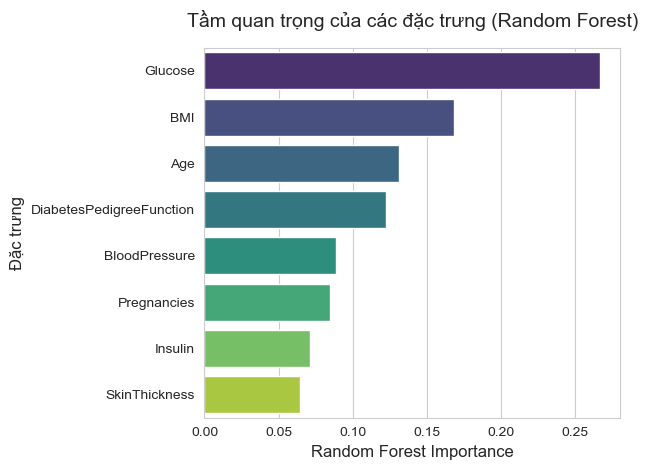

In [30]:
# 5. Vẽ biểu đồ thanh với palette màu chuyển sắc 'viridis' hoặc 'crest'
# Ở đây dùng palette 'viridis' để có màu từ tím đến vàng xanh giống hình
sns.barplot(data=df_importance, 
            x='Importance', 
            y='Feature', 
            palette='viridis')

# 6. Tùy chỉnh tiêu đề và nhãn trục
plt.title('Tầm quan trọng của các đặc trưng (Random Forest)', fontsize=14, pad=15)
plt.xlabel('Random Forest Importance', fontsize=12)
plt.ylabel('Đặc trưng', fontsize=12)

plt.tight_layout()
plt.show()

In [32]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
# Tách đặc trưng (X), loại bỏ biến mục tiêu 'Outcome'
X = data.drop('Outcome', axis=1)

# 3. Thêm hằng số (intercept) - Bắt buộc để tính VIF chính xác
X_vif = add_constant(X)

# 4. Tính toán VIF cho từng đặc trưng
vif_data = pd.DataFrame()
vif_data["Feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i+1) for i in range(len(X.columns))]

# 5. Thêm cột Đánh giá dựa trên ngưỡng VIF
# Ngưỡng thông thường: VIF < 5 là Tốt, VIF > 10 là Đa cộng tuyến nghiêm trọng
vif_data["Đánh giá"] = vif_data["VIF"].apply(lambda x: "Tốt" if x < 5 else "Cần xem xét")

# 6. Sắp xếp theo VIF giảm dần để giống hình mẫu
vif_data = vif_data.sort_values(by="VIF", ascending=False).reset_index(drop=True)

In [33]:
print(vif_data)

                    Feature       VIF Đánh giá
0                       Age  1.588368      Tốt
1             SkinThickness  1.507432      Tốt
2               Pregnancies  1.430872      Tốt
3                   Insulin  1.427536      Tốt
4                   Glucose  1.298961      Tốt
5                       BMI  1.297450      Tốt
6             BloodPressure  1.181863      Tốt
7  DiabetesPedigreeFunction  1.067090      Tốt


C:\Users\Dat\AppData\Local\Temp\ipykernel_6876\676023290.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=vif_data,


<Axes: xlabel='VIF', ylabel='Feature'>

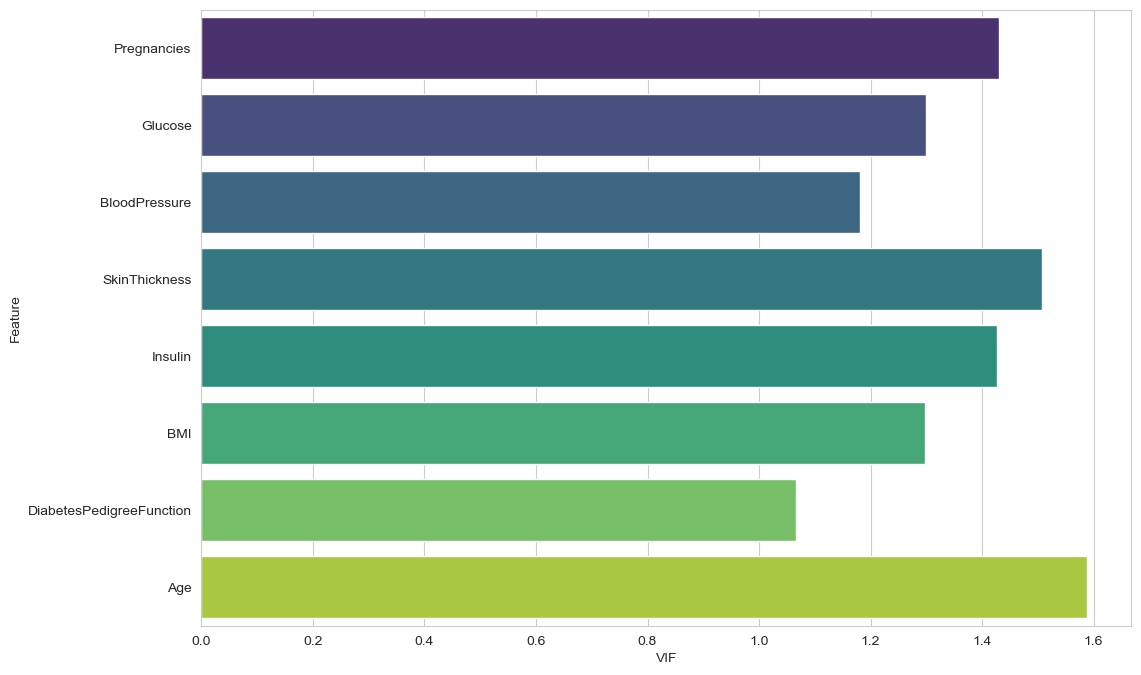

In [34]:
# 2. Tính toán VIF
X = data.drop('Outcome', axis=1)
X_const = add_constant(X)
vif_data = pd.DataFrame()
vif_data["Feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X_const.values, i+1) for i in range(len(X.columns))]

# 3. Cấu hình giao diện vẽ hình
plt.figure(figsize=(12, 8))
sns.set_style("whitegrid")

# 4. Vẽ biểu đồ thanh với palette màu 'viridis' (giống hình 5.7)
# Lưu ý: Ở đây chúng ta giữ nguyên thứ tự biến gốc hoặc sắp xếp tùy ý
sns.barplot(data=vif_data, 
            x='VIF', 
            y='Feature', 
            palette='viridis')